# Basic Usage Examples

This notebook walks through representative data processing patterns to show what you can do with limulus.

In [1]:
import limulus
import pandas as pd
import polars as pl

iris_data = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv')

session = limulus.Session()
session.loads({"iris": iris_data})

## Example 1: Common Syntax


In [2]:
session.submit("""
data ratios;
  set iris;
  sepal_ratio = round(sepal_length / sepal_width, 0.01);
  petal_area = round(petal_length * petal_width, 0.01); 
  keep species sepal_length sepal_width sepal_ratio petal_area;
run;
""")

print(pl.from_arrow(session["ratios"]).head(5))

shape: (5, 5)
┌─────────┬──────────────┬─────────────┬─────────────┬────────────┐
│ species ┆ sepal_length ┆ sepal_width ┆ sepal_ratio ┆ petal_area │
│ ---     ┆ ---          ┆ ---         ┆ ---         ┆ ---        │
│ str     ┆ f64          ┆ f64         ┆ f64         ┆ f64        │
╞═════════╪══════════════╪═════════════╪═════════════╪════════════╡
│ setosa  ┆ 5.1          ┆ 3.5         ┆ 1.46        ┆ 0.28       │
│ setosa  ┆ 4.9          ┆ 3.0         ┆ 1.63        ┆ 0.28       │
│ setosa  ┆ 4.7          ┆ 3.2         ┆ 1.47        ┆ 0.26       │
│ setosa  ┆ 4.6          ┆ 3.1         ┆ 1.48        ┆ 0.3        │
│ setosa  ┆ 5.0          ┆ 3.6         ┆ 1.39        ┆ 0.28       │
└─────────┴──────────────┴─────────────┴─────────────┴────────────┘


## Example 2: DO–END and Multiple Output Datasets


In [3]:
session.submit("""
data large_petal small_petal;
  set iris;
  if petal_length > 2.0 then do ;
    size_group = "large" ;
    output large_petal;
  end ;
  else do ;
    size_group = "small" ;
    output small_petal;
  end ;
run;
""")

# 2 ways convert to polars
print(pl.from_arrow(session["large_petal"]).head(3))
print(session.dataset("small_petal").to_polars().head(3))

shape: (3, 6)
┌──────────────┬─────────────┬──────────────┬─────────────┬────────────┬────────────┐
│ sepal_length ┆ sepal_width ┆ petal_length ┆ petal_width ┆ species    ┆ size_group │
│ ---          ┆ ---         ┆ ---          ┆ ---         ┆ ---        ┆ ---        │
│ f64          ┆ f64         ┆ f64          ┆ f64         ┆ str        ┆ str        │
╞══════════════╪═════════════╪══════════════╪═════════════╪════════════╪════════════╡
│ 7.0          ┆ 3.2         ┆ 4.7          ┆ 1.4         ┆ versicolor ┆ large      │
│ 6.4          ┆ 3.2         ┆ 4.5          ┆ 1.5         ┆ versicolor ┆ large      │
│ 6.9          ┆ 3.1         ┆ 4.9          ┆ 1.5         ┆ versicolor ┆ large      │
└──────────────┴─────────────┴──────────────┴─────────────┴────────────┴────────────┘
shape: (3, 6)
┌──────────────┬─────────────┬──────────────┬─────────────┬─────────┬────────────┐
│ sepal_length ┆ sepal_width ┆ petal_length ┆ petal_width ┆ species ┆ size_group │
│ ---          ┆ ---         ┆ -

## Example 3: `BY` Group Processing (`RETAIN` + `FIRST.` / `LAST.`)


In [4]:
session.submit("""
data avg_petal;
  set ratios;
  by species;
  retain area_sum 0 area_count 0;

  if first.species then do;
    area_sum = 0;
    area_count = 0;
  end;

  area_sum + petal_area;
  area_count + 1;

  if last.species then do;
    avg_petal_area = round(area_sum / area_count, 0.01);
    output;
  end;

  keep species area_count avg_petal_area;
run;
""")

print(session.dataset("avg_petal").to_polars())

shape: (3, 3)
┌────────────┬────────────┬────────────────┐
│ species    ┆ area_count ┆ avg_petal_area │
│ ---        ┆ ---        ┆ ---            │
│ str        ┆ f64        ┆ f64            │
╞════════════╪════════════╪════════════════╡
│ setosa     ┆ 50.0       ┆ 0.37           │
│ versicolor ┆ 50.0       ┆ 5.72           │
│ virginica  ┆ 50.0       ┆ 11.3           │
└────────────┴────────────┴────────────────┘


## Example 4: Joining Data


In [5]:

# Create a species lookup table
species_info = pl.DataFrame({
    "species": ["setosa", "versicolor", "virginica"],
    "category": ["small", "medium", "large"],
})
session.loads({"species_info": species_info})

session.submit("""
/* Vertical concatenation */
data iris_doubled ;
  set iris(in=in1) iris ;
  if in1 = 1 then tag = "first" ;
  else tag = "second" ;
run ;

/* Horizontal join */
data iris_labeled;
  merge iris(in=in1) species_info;
  by species ;
  if in1 ;
run;
""")

print("rows:", session["iris_doubled"].shape[0])
print(session.dataset("iris_labeled").to_polars().head(5))


rows: 300
shape: (5, 6)
┌──────────────┬─────────────┬──────────────┬─────────────┬─────────┬──────────┐
│ sepal_length ┆ sepal_width ┆ petal_length ┆ petal_width ┆ species ┆ category │
│ ---          ┆ ---         ┆ ---          ┆ ---         ┆ ---     ┆ ---      │
│ f64          ┆ f64         ┆ f64          ┆ f64         ┆ str     ┆ str      │
╞══════════════╪═════════════╪══════════════╪═════════════╪═════════╪══════════╡
│ 5.1          ┆ 3.5         ┆ 1.4          ┆ 0.2         ┆ setosa  ┆ small    │
│ 4.9          ┆ 3.0         ┆ 1.4          ┆ 0.2         ┆ setosa  ┆ small    │
│ 4.7          ┆ 3.2         ┆ 1.3          ┆ 0.2         ┆ setosa  ┆ small    │
│ 4.6          ┆ 3.1         ┆ 1.5          ┆ 0.2         ┆ setosa  ┆ small    │
│ 5.0          ┆ 3.6         ┆ 1.4          ┆ 0.2         ┆ setosa  ┆ small    │
└──────────────┴─────────────┴──────────────┴─────────────┴─────────┴──────────┘


## Example 5: Integration with Python

Here we combine Python processing before and after the Data Step.  
As an example, we run a loop to compute sepal area by species and display scatter plots with matplotlib.  


species=setosa: 50 rows, mean sepal_area=17.26


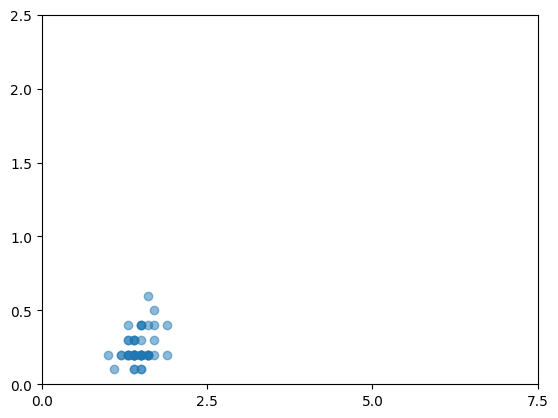

species=versicolor: 50 rows, mean sepal_area=16.53


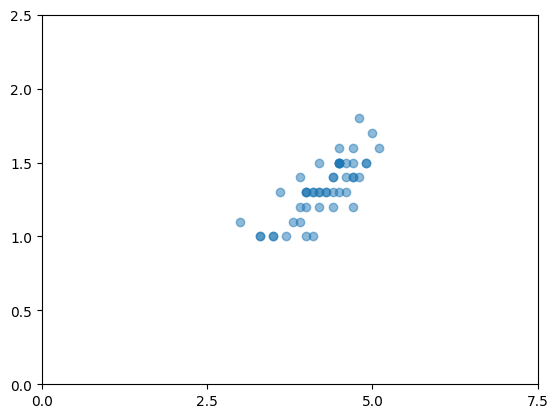

species=virginica: 50 rows, mean sepal_area=19.68


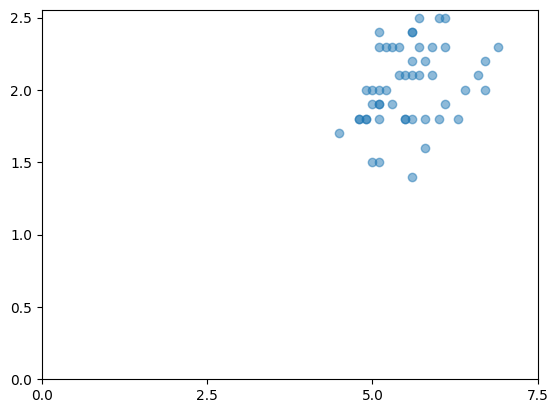

In [6]:
import matplotlib.pyplot as plt

for sp in ["setosa", "versicolor", "virginica"]:
    session.submit(f"""
    data sepal_{sp} ;
      set iris ;
      where species = "{sp}" ;
      sepal_area = round(sepal_length * sepal_width, 0.01) ;
      keep species sepal_area petal_length petal_width;
    run ;
    """)

    out = session[f"sepal_{sp}"].to_pandas()
    print(f"species={sp}: {len(out)} rows, mean sepal_area={out['sepal_area'].mean():.2f}")
         
    plt.figure()
    plt.scatter(out["petal_length"], out["petal_width"], alpha=0.5)
    plt.yticks([0, 0.5, 1.0, 1.5, 2.0, 2.5])
    plt.xticks([0, 2.5, 5.0, 7.5])
    plt.show()  
    plt.close()
